In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import plotly.graph_objects as go
import plotly.express as px
from scipy.signal import savgol_filter


# Importing and Cleaning the Data

In [5]:
df = pd.read_csv('Data/nyt_president.csv')

In [6]:
df.head()

,poll_id,pollster_id,pollster,sponsor_ids,sponsors,display_name,pollster_rating_id,pollster_rating_name,numeric_grade,pollscore,...,url_topline,url_crosstab,source,internal,partisan,politician,politician_id,yes,no,alternate_answers
0,9f87c793-4cef-4008-84d7-a403d9e40d8a,5a7ec4cc-59c7-44e0-b7c0-e78c05f19438,GBAO,"2d85208a-737f-45c9-98f2-d3d7e1eeac67,4d929913-...",Care in Action | Community Change Action | FWD.us,GBAO,109.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Donald Trump,NaN,43.0,57.0,NaN
1,426a32fd-aeb3-4220-a8d9-28d0317c7165,c429da10-5aa0-445e-9800-039c0a295b43,SurveyMonkey,4678387e-860f-4e2a-901e-183baf18cf83,NBC News Decision Desk,SurveyMonkey,324.0,SurveyMonkey,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Donald Trump,NaN,39.0,61.0,NaN
2,0936b486-6693-4ba2-908b-7646a89b62c7,59ef5d62-c6ba-41a3-b2cd-24b8543e62b9,YouGov,146144a2-08d6-4c6b-b912-f067ed647252,Economist,YouGov,391.0,YouGov,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Donald Trump,NaN,37.0,56.0,6.0
3,0936b486-6693-4ba2-908b-7646a89b62c7,59ef5d62-c6ba-41a3-b2cd-24b8543e62b9,YouGov,146144a2-08d6-4c6b-b912-f067ed647252,Economist,YouGov,391.0,YouGov,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Donald Trump,NaN,40.0,57.0,3.0
4,77b02317-04b6-4540-800a-8a665f6f51f8,4bc528cc-f55c-4f8b-8c90-adfe09f46c76,Morning Consult,NaN,NaN,Morning Consult,218.0,Morning Consult,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Donald Trump,NaN,40.0,54.2,5.8


In [7]:
list(df)

['poll_id',
 'pollster_id',
 'pollster',
 'sponsor_ids',
 'sponsors',
 'display_name',
 'pollster_rating_id',
 'pollster_rating_name',
 'numeric_grade',
 'pollscore',
 'methodology',
 'transparency_score',
 'state',
 'start_date',
 'end_date',
 'sponsor_candidate_id',
 'sponsor_candidate',
 'sponsor_candidate_party',
 'question_id',
 'sample_size',
 'population',
 'subpopulation',
 'population_full',
 'tracking',
 'created_at',
 'notes',
 'url',
 'url_article',
 'url_topline',
 'url_crosstab',
 'source',
 'internal',
 'partisan',
 'politician',
 'politician_id',
 'yes',
 'no',
 'alternate_answers']

In [8]:
table_one = df[['end_date','numeric_grade','pollscore', 'transparency_score', 'sample_size', 'partisan', 'yes', 'no']]

In [9]:
table_one.head()

,end_date,numeric_grade,pollscore,transparency_score,sample_size,partisan,yes,no
0,2/9/26,NaN,NaN,NaN,1000.0,NaN,43.0,57.0
1,2/6/26,NaN,NaN,NaN,21995.0,NaN,39.0,61.0
2,2/9/26,NaN,NaN,NaN,1730.0,NaN,37.0,56.0
3,2/9/26,NaN,NaN,NaN,1551.0,NaN,40.0,57.0
4,2/8/26,NaN,NaN,NaN,NaN,NaN,40.0,54.2


In [10]:
print(table_one['pollscore'].isnull().sum() == len(table_one))
print(table_one['numeric_grade'].isnull().sum() == len(table_one))
print(table_one['transparency_score'].isnull().sum() == len(table_one))
print(table_one['partisan'].isnull().sum() == len(table_one))

True
True
True
False


In [11]:
table_one['partisan'].isnull().sum()

np.int64(726)

In [12]:
df_two = df[['end_date','sample_size','yes', 'no']].dropna()
print(len(df_two))
df_two

734


,end_date,sample_size,yes,no
0,2/9/26,1000.0,43.0,57.0
1,2/6/26,21995.0,39.0,61.0
2,2/9/26,1730.0,37.0,56.0
3,2/9/26,1551.0,40.0,57.0
5,2/5/26,1000.0,44.0,54.0
...,...,...,...,...
760,1/22/25,2979.0,55.5,37.4
761,1/23/25,1882.0,50.1,49.7
762,1/21/25,742.0,49.0,36.0
763,1/21/25,1077.0,47.0,41.0


In [13]:
df_two['end_date'] = pd.to_datetime(table_one['end_date'])
df_two

C:\Users\Midnight\AppData\Local\Temp\ipykernel_8040\4215076847.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_two['end_date'] = pd.to_datetime(table_one['end_date'])


,end_date,sample_size,yes,no
0,2026-02-09,1000.0,43.0,57.0
1,2026-02-06,21995.0,39.0,61.0
2,2026-02-09,1730.0,37.0,56.0
3,2026-02-09,1551.0,40.0,57.0
5,2026-02-05,1000.0,44.0,54.0
...,...,...,...,...
760,2025-01-22,2979.0,55.5,37.4
761,2025-01-23,1882.0,50.1,49.7
762,2025-01-21,742.0,49.0,36.0
763,2025-01-21,1077.0,47.0,41.0


In [14]:
df_two['sample_size'].mean()

np.float64(1834.33378746594)

# Creating Graphs using Matplotlib

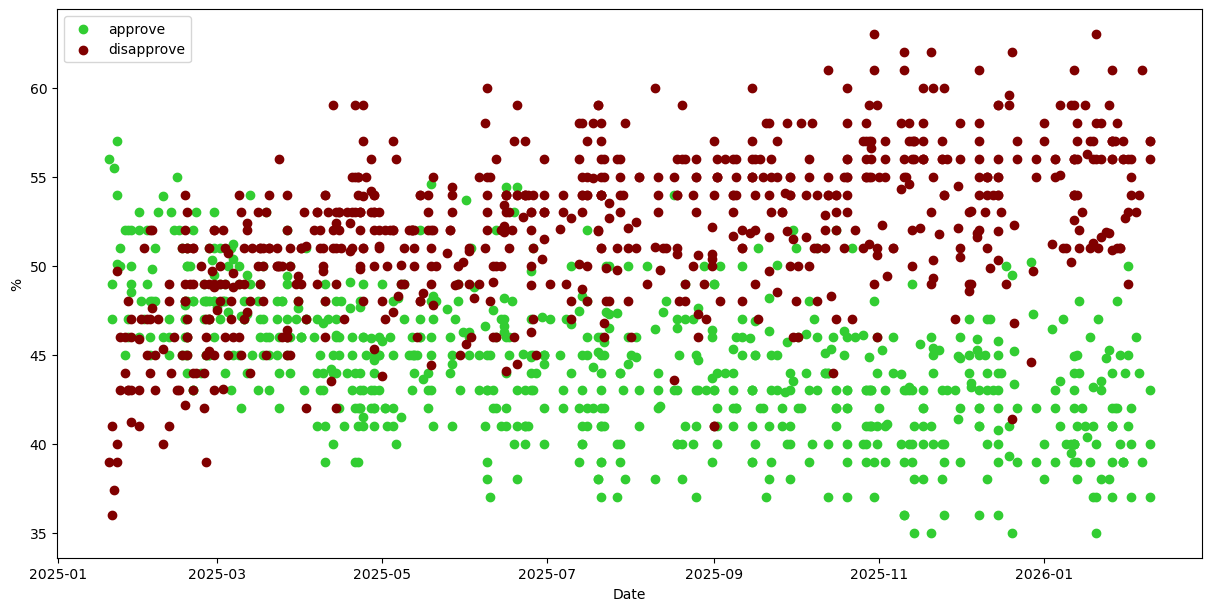

In [15]:
fig, ax = plt.subplots(figsize=(12,6), layout='constrained')
ax.scatter(df_two['end_date'], df_two['yes'], label='approve', c='limegreen')
ax.scatter(df_two['end_date'], df_two['no'], label='disapprove', c='maroon')
ax.set_xlabel('Date')
ax.set_ylabel('%')
ax.legend()

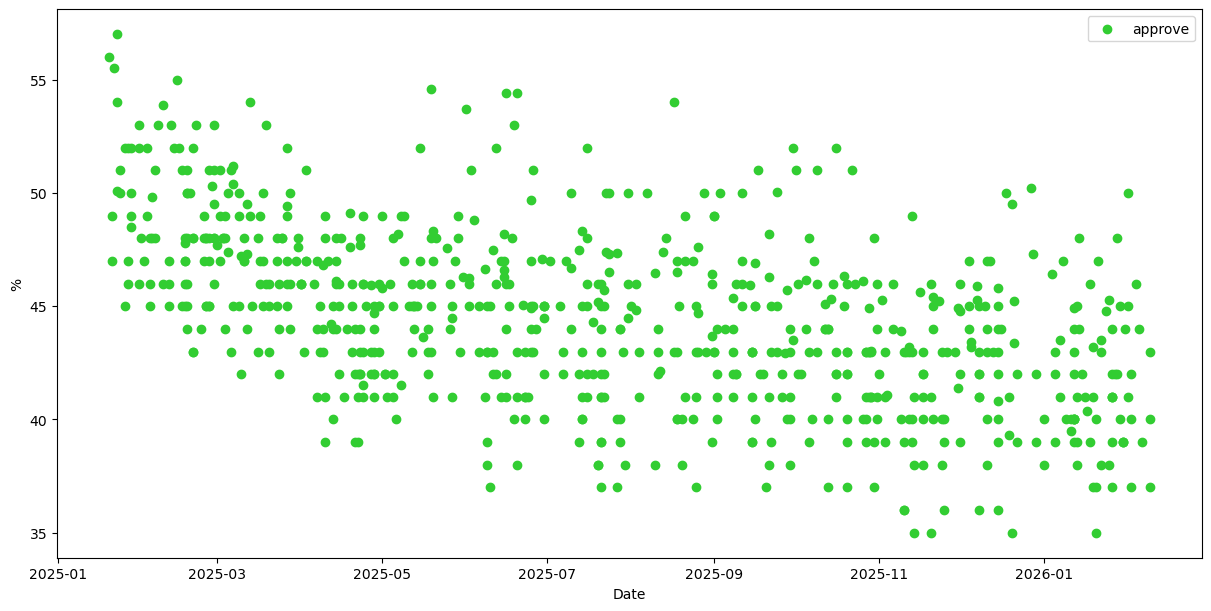

In [16]:
fig, ax = plt.subplots(figsize=(12,6), layout='constrained')
ax.scatter(df_two['end_date'], df_two['yes'], label='approve', c='limegreen')
ax.set_xlabel('Date')
ax.set_ylabel('%')
ax.legend()

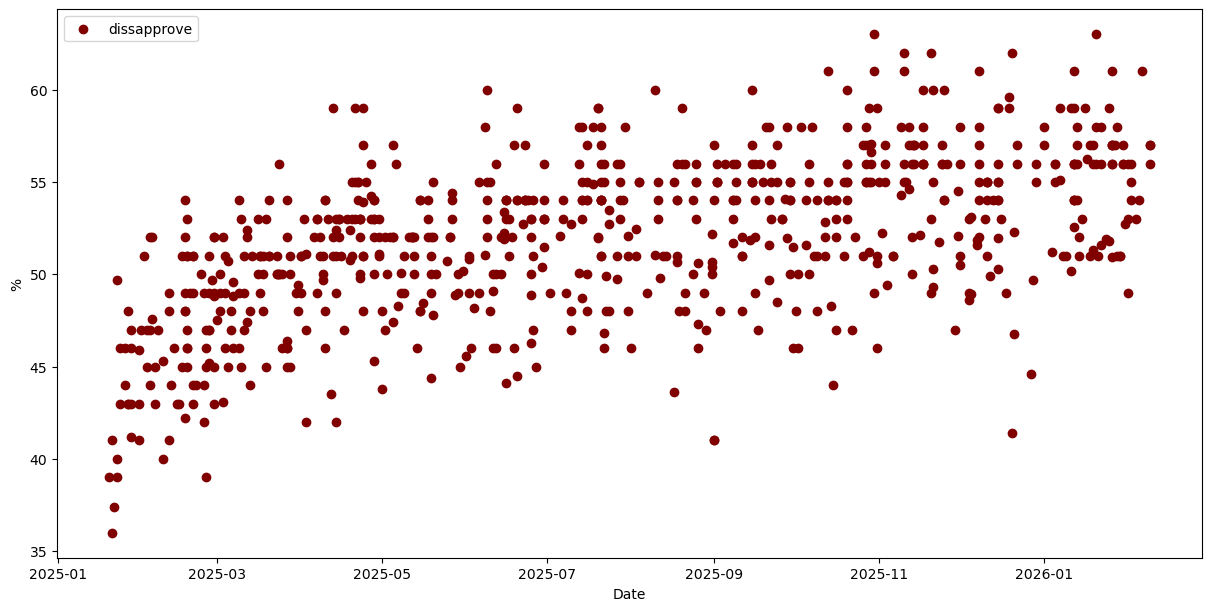

In [17]:
fig, ax = plt.subplots(figsize=(12,6), layout='constrained')
ax.scatter(df_two['end_date'], df_two['no'], label='dissapprove', c='maroon')
ax.set_xlabel('Date')
ax.set_ylabel('%')
ax.legend()

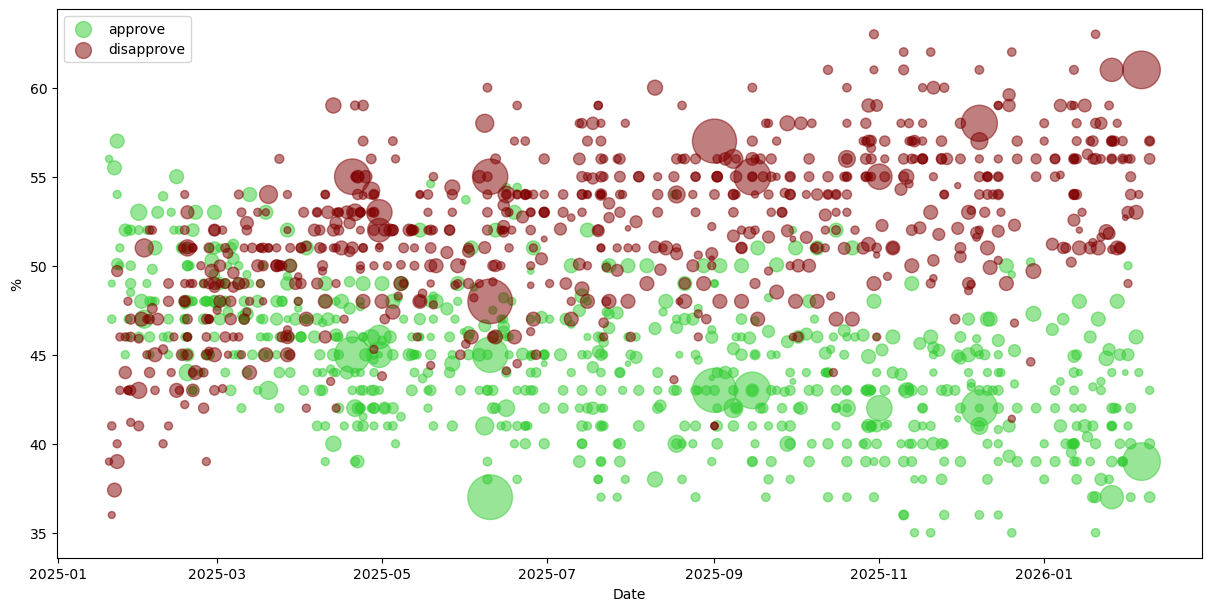

In [18]:
fig, ax = plt.subplots(figsize=(12,6), layout='constrained')
ax.scatter(df_two['end_date'], df_two['yes'], label='approve', c='limegreen', alpha =0.5, s=df_two['sample_size'] / 30)
ax.scatter(df_two['end_date'], df_two['no'], label='disapprove', c='maroon', alpha=0.5, s=df_two['sample_size'] / 30)
ax.set_xlabel('Date')
ax.set_ylabel('%')
ax.legend(markerscale= 0.5)


# Trying new lines and graphs

# Summing polls and taking weighted Average for Loess

In [19]:
df_two.nunique()

end_date       292
sample_size    385
yes            117
no             133
dtype: int64

In [20]:
def weighted_avg(group, col):
    return (group[col] * group['sample_size']).sum() / group['sample_size'].sum()

result = (
    df_two.groupby('end_date')
    .apply(lambda g: pd.Series({
        'yes': round(weighted_avg(g, 'yes'), 1),
        'no': round(weighted_avg(g, 'no'), 1)
    }), include_groups=False)
    .reset_index()
)

In [21]:
result

,end_date,yes,no
0,2025-01-20,56.0,39.0
1,2025-01-21,47.8,39.0
2,2025-01-22,55.5,37.4
3,2025-01-23,54.3,42.6
4,2025-01-24,50.5,44.5
...,...,...,...
287,2026-02-02,39.9,54.9
288,2026-02-04,46.0,53.0
289,2026-02-05,44.0,54.0
290,2026-02-06,39.0,61.0


In [22]:
result[result['yes'] + result['no'] > 100]

,end_date,yes,no


In [23]:
#result.to_csv("approvals_test_data.csv",  encoding='utf-8', index=False)

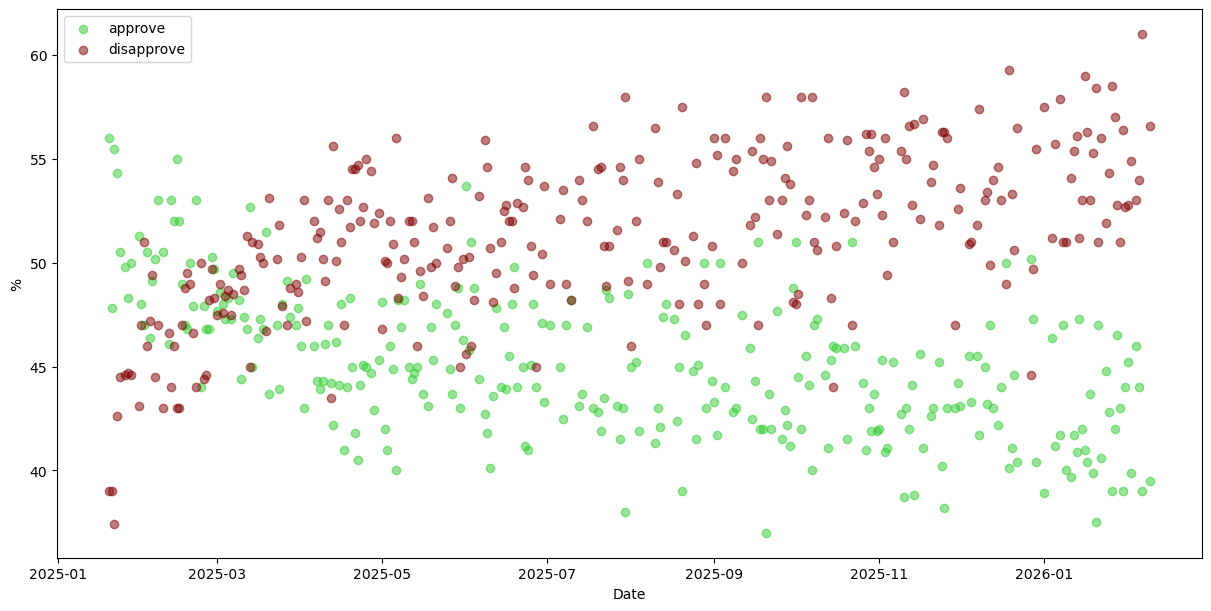

In [24]:
fig, ax = plt.subplots(figsize=(12,6), layout='constrained')
ax.scatter(result['end_date'], result['yes'], label='approve', c='limegreen', alpha =0.5)
ax.scatter(result['end_date'], result['no'], label='disapprove', c='maroon', alpha=0.5)
ax.set_xlabel('Date')
ax.set_ylabel('%')
ax.legend()

In [25]:
lowess = sm.nonparametric.lowess
yes = lowess(result['yes'], result['end_date'], is_sorted=True, xvals=result['end_date'], frac=0.2, it=1)
no = lowess(result['no'], result['end_date'], is_sorted=True, xvals=result['end_date'], frac=0.2, it=1)

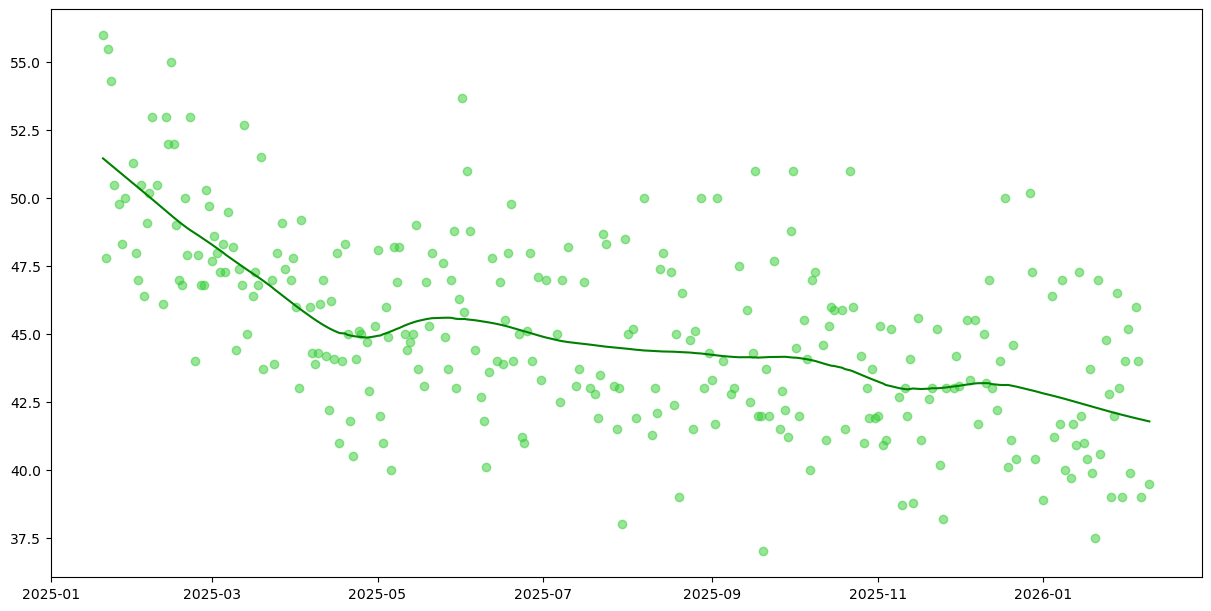

In [26]:
fig, ax = plt.subplots(figsize=(12,6), layout='constrained')
ax.scatter(result['end_date'], result['yes'], label='approve', c='limegreen', alpha =0.5)
ax.plot(result['end_date'], yes, c='green')

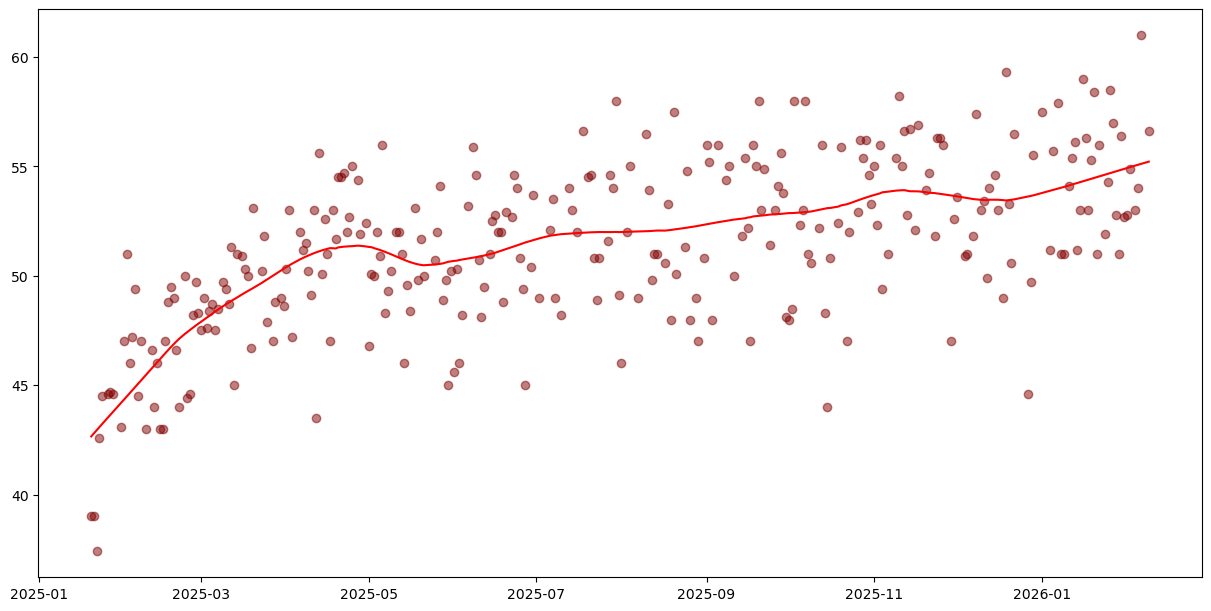

In [27]:
fig, ax = plt.subplots(figsize=(12,6), layout='constrained')
ax.scatter(result['end_date'], result['no'], label='approve', c='maroon', alpha =0.5)
ax.plot(result['end_date'], no, c='red')

# Creating Graphs using Plotly

## Using Plotly Express and statsmodel loess

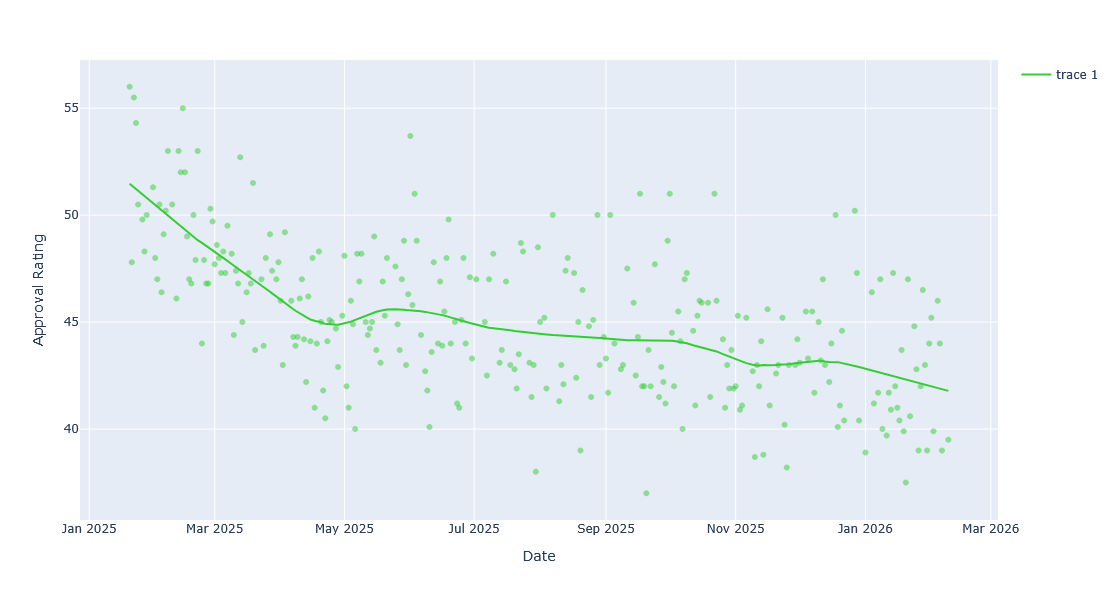

In [28]:
fig = px.scatter(
    result, x="end_date", y="yes", 
    labels={"end_date" : "Date", "yes" : "Approval Rating"},
    color_discrete_sequence=['limegreen'],
)

fig.add_trace(go.Scatter(x=result['end_date'], y=yes, mode="lines", line=dict(color='limegreen'))
)

fig.update_layout(width=1000, height=600)
fig.update_traces(marker=dict(opacity=0.5))

## Using Plotly Express and built-in loess

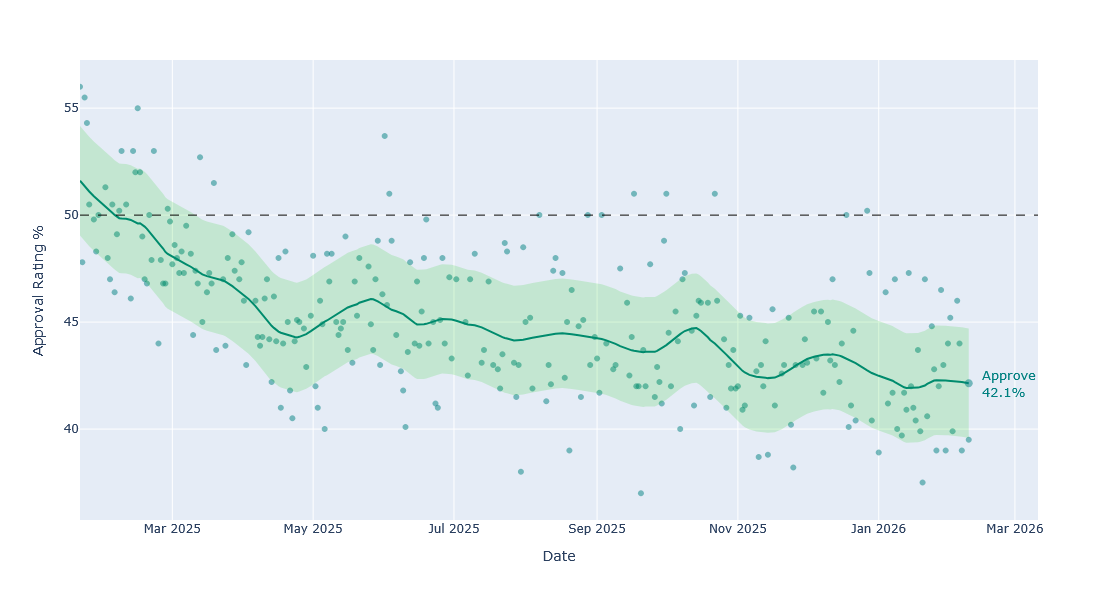

In [29]:
fig = px.scatter(
    result, x="end_date", y="yes", 
    labels={"end_date" : "Date", "yes" : "Approval Rating %"},
    color_discrete_sequence=['teal'],
    trendline="lowess",
    trendline_options=dict(frac=0.1)
)

trendline_trace = fig.data[1]

smoothed_y = trendline_trace.y  
raw_y = result['yes'].values

residuals = raw_y - smoothed_y
std = residuals.std()

upper = smoothed_y + 0.96 * std
lower = smoothed_y - 0.96 * std

last_date = trendline_trace.x[-1]
last_val = trendline_trace.y[-1]

fig.add_trace(go.Scatter(
    x=trendline_trace.x, y=lower,
    mode='lines', line=dict(width=0),
    showlegend=False
), row=None)  

fig.add_trace(go.Scatter(
    x=trendline_trace.x, y=upper,
    mode='lines', line=dict(width=0),
    fill='tonexty', fillcolor='rgba(0,200,0,0.15)',
    showlegend=False
))

fig.add_annotation(
    x=last_date,
    y=last_val,
    text=f"Approve<br>{last_val:.1f}%",
    showarrow=False,
    xanchor="left",
    xshift=10,
    font=dict(size=13, color="teal"),
    align="left"
)

fig.add_trace(go.Scatter(
    x=[last_date],
    y=[last_val],
    mode="markers",
    marker=dict(size=8, color="teal"),
    showlegend=False
))

fig.update_xaxes(range=[result['end_date'].min(), last_date + pd.Timedelta(days=30)])


fig.update_layout(width=1000, height=600)
fig.update_traces(marker=dict(opacity=0.5))
fig.add_hline(y=50, line=dict(color="black", dash="dash", width=1))

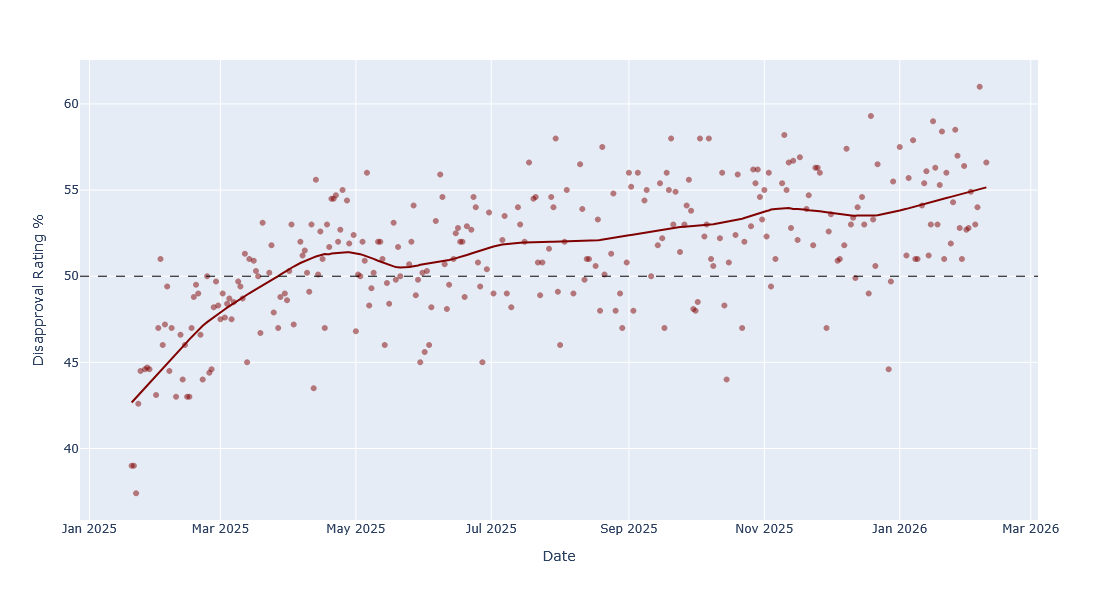

In [30]:
fig = px.scatter(
    result, x="end_date", y="no", 
    labels={"end_date" : "Date", "no" : "Disapproval Rating %"},
    color_discrete_sequence=['maroon'],
    trendline="lowess",
    trendline_options=dict(frac=0.2)
)
fig.update_layout(width=1000, height=600)
fig.update_traces(marker=dict(opacity=0.5))

fig.add_hline(y=50, line=dict(color="black", dash="dash", width=1))

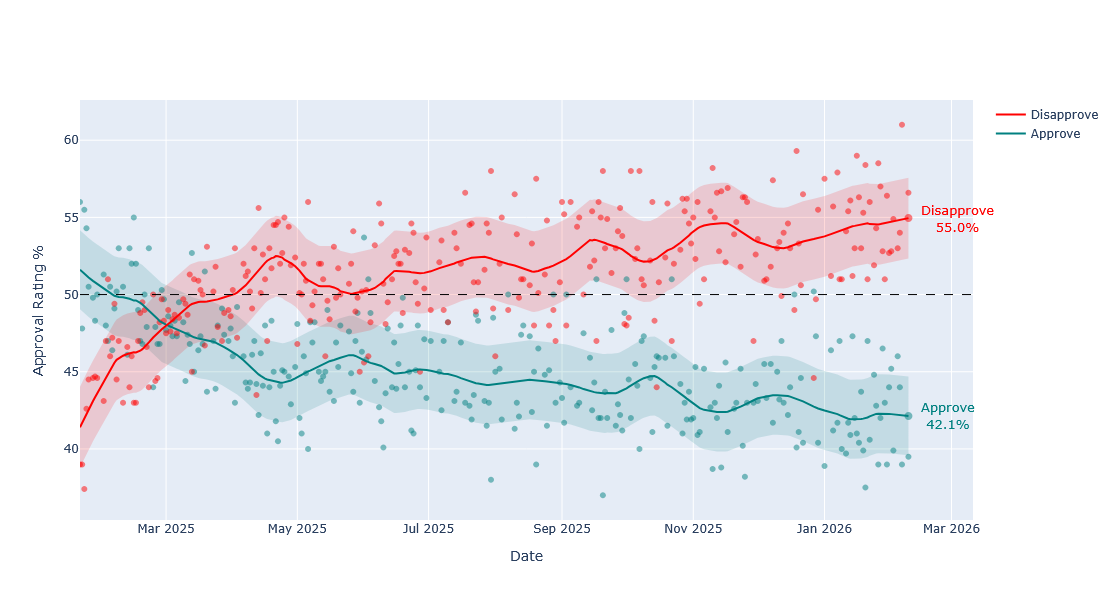

In [31]:
# --- Approval (yes) ---
fig_yes = px.scatter(
    result, x="end_date", y="yes",
    color_discrete_sequence=['teal'],
    trendline="lowess",
    trendline_options=dict(frac=0.1)
)
yes_trace = fig_yes.data[1]
smoothed_yes = yes_trace.y
residuals_yes = result['yes'].values - smoothed_yes
std_yes = residuals_yes.std()
upper_yes = smoothed_yes + 0.96 * std_yes
lower_yes = smoothed_yes - 0.96 * std_yes

# --- Disapproval (no) ---
fig_no = px.scatter(
    result, x="end_date", y="no",
    color_discrete_sequence=['red'],
    trendline="lowess",
    trendline_options=dict(frac=0.1)
)
no_trace = fig_no.data[1]
smoothed_no = no_trace.y
residuals_no = result['no'].values - smoothed_no
std_no = residuals_no.std()
upper_no = smoothed_no + 0.96 * std_no
lower_no = smoothed_no - 0.96 * std_no

# --- Combine into one figure ---
fig = go.Figure()

# Approval band
fig.add_trace(go.Scatter(x=yes_trace.x, y=lower_yes, mode='lines', line=dict(width=0), showlegend=False))
fig.add_trace(go.Scatter(x=yes_trace.x, y=upper_yes, mode='lines', line=dict(width=0), fill='tonexty', fillcolor='rgba(0,128,128,0.15)', showlegend=False))

# Disapproval band
fig.add_trace(go.Scatter(x=no_trace.x, y=lower_no, mode='lines', line=dict(width=0), showlegend=False))
fig.add_trace(go.Scatter(x=no_trace.x, y=upper_no, mode='lines', line=dict(width=0), fill='tonexty', fillcolor='rgba(255,0,0,0.15)', showlegend=False))

# Scatter points
for trace in fig_yes.data[0:1]:
    fig.add_trace(trace)
for trace in fig_no.data[0:1]:
    fig.add_trace(trace)

# Smooth lines
fig.add_trace(go.Scatter(x=yes_trace.x, y=smoothed_yes, mode='lines', line=dict(color='teal', width=2), name='Approve'))
fig.add_trace(go.Scatter(x=no_trace.x, y=smoothed_no, mode='lines', line=dict(color='red', width=2), name='Disapprove'))

# End point annotations and markers
last_date = yes_trace.x[-1]
fig.add_annotation(x=last_date, y=smoothed_yes[-1], text=f"Approve<br>{smoothed_yes[-1]:.1f}%", showarrow=False, xanchor="left", xshift=10, font=dict(size=13, color="teal"))
fig.add_annotation(x=last_date, y=smoothed_no[-1], text=f"Disapprove<br>{smoothed_no[-1]:.1f}%", showarrow=False, xanchor="left", xshift=10, font=dict(size=13, color="red"))
fig.add_trace(go.Scatter(x=[last_date], y=[smoothed_yes[-1]], mode="markers", marker=dict(size=8, color="teal"), showlegend=False))
fig.add_trace(go.Scatter(x=[last_date], y=[smoothed_no[-1]], mode="markers", marker=dict(size=8, color="red"), showlegend=False))

# Layout
fig.update_layout(
    width=1000, height=600,
    xaxis_title="Date",
    yaxis_title="Approval Rating %"
)

fig.update_traces(marker=dict(opacity=0.5))
fig.update_xaxes(range=[result['end_date'].min(), last_date + pd.Timedelta(days=30)])
fig.add_hline(y=50, line=dict(color="black", dash="dash", width=1))
